In [1]:
from entsoe import EntsoePandasClient
from entsoe.exceptions import NoMatchingDataError, PaginationError
from requests.exceptions import HTTPError

import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path


API_KEY = "1206c24a-2fb6-4ec3-a47f-0e1be10dacd4"
client = EntsoePandasClient(api_key= API_KEY)
start = pd.Timestamp("2024-01-01", tz="Europe/Brussels")
end   = pd.Timestamp("2025-01-01", tz="Europe/Brussels")

In [2]:
df_unique = client.query_contracted_reserve_prices(
                country_code= "NL",
                start=start, end=end,
                process_type="A51",
                type_marketagreement_type="A01",
                psr_type=None
            )


In [3]:
print(df_unique.head(20))
print(df_unique.tail(20))

                           Down     Up
2024-01-01 00:00:00+01:00  16.9  11.16
2024-01-01 00:15:00+01:00  16.9  11.16
2024-01-01 00:30:00+01:00  16.9  11.16
2024-01-01 00:45:00+01:00  16.9  11.16
2024-01-01 01:00:00+01:00  16.9  11.16
2024-01-01 01:15:00+01:00  16.9  11.16
2024-01-01 01:30:00+01:00  16.9  11.16
2024-01-01 01:45:00+01:00  16.9  11.16
2024-01-01 02:00:00+01:00  16.9  11.16
2024-01-01 02:15:00+01:00  16.9  11.16
2024-01-01 02:30:00+01:00  16.9  11.16
2024-01-01 02:45:00+01:00  16.9  11.16
2024-01-01 03:00:00+01:00  16.9  11.16
2024-01-01 03:15:00+01:00  16.9  11.16
2024-01-01 03:30:00+01:00  16.9  11.16
2024-01-01 03:45:00+01:00  16.9  11.16
2024-01-01 04:00:00+01:00  16.9  11.16
2024-01-01 04:15:00+01:00  16.9  11.16
2024-01-01 04:30:00+01:00  16.9  11.16
2024-01-01 04:45:00+01:00  16.9  11.16
                           Down    Up
2024-12-31 19:15:00+01:00  1.44  4.19
2024-12-31 19:30:00+01:00  1.44  4.19
2024-12-31 19:45:00+01:00  1.44  4.19
2024-12-31 20:00:00+01:00  1.

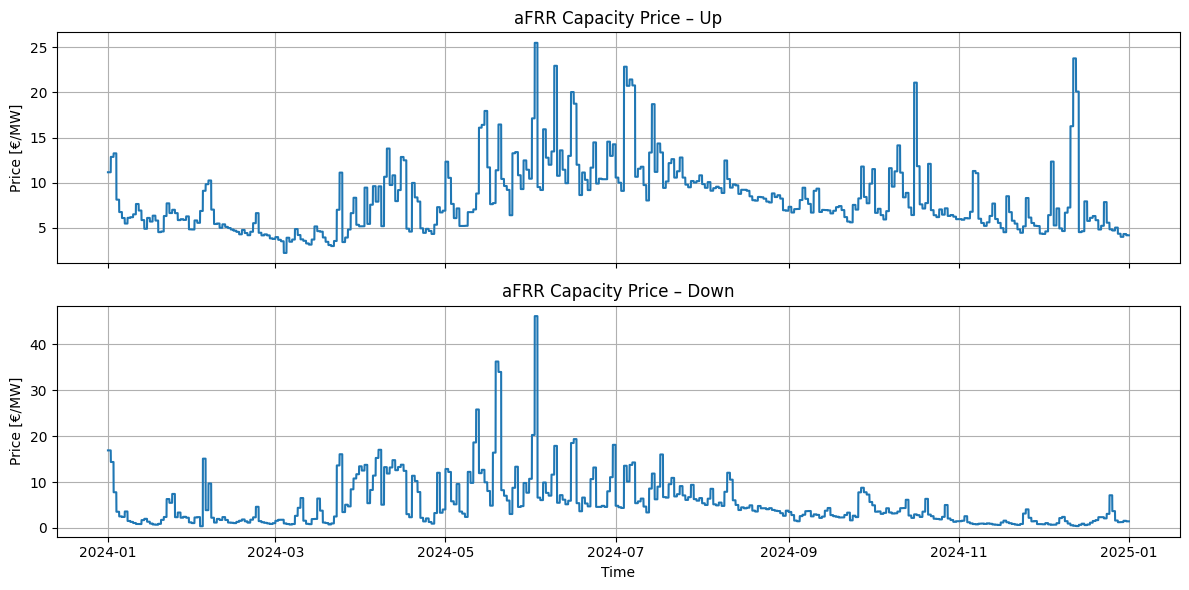

In [ ]:
df_unique = df_unique.sort_index()   # just to be safe

fig, (ax_up, ax_down) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True
)

ax_up.plot(df_unique.index, df_unique['Up'])
ax_up.set_title('aFRR Capacity Price – Up')
ax_up.set_ylabel('Price [€/MW]')
ax_up.grid(True)

ax_down.plot(df_unique.index, df_unique['Down'])
ax_down.set_title('aFRR Capacity Price – Down')
ax_down.set_ylabel('Price [€/MW]')
ax_down.set_xlabel('Time')
ax_down.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
df_unique = (
    df_unique
    .rename_axis("datetime") 
    .reset_index()           
)
data_folder = Path.cwd()/"CSV"
df_unique.to_csv(data_folder/"capacity_aFRR_NL.csv", index=False)
